In [ ]:
# ============================================================================
# Cell 1: Import Libraries and Setup
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm
from sklearn.model_selection import train_test_split
import time
import scipy.io as sio
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")

✓ Libraries imported successfully!
NumPy version: 2.0.2


In [ ]:
# ============================================================================
# Cell 2: Upload and Load DNS Data (.mat file)
# ============================================================================

print("=" * 60)
print("Please upload your .mat file containing DNS data")
print("=" * 60)

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

data = sio.loadmat(file_name)

print(f"\n✓ File loaded: {file_name}")
print(f"Keys in file: {list(data.keys())}")

# Check for expected variables
expected_vars = ['C_eff_data', 'D_p1', 'D_p2', 'C_p1', 'C_p2', 'N', 'vol_frac']
for var in expected_vars:
    if var in data:
        print(f"  ✓ {var} shape: {data[var].shape}")
    else:
        print(f"  ✗ {var} NOT found")

# Get number of samples
n_total_samples = data['C_eff_data'].shape[2]
print(f"\n✓ Total samples in dataset: {n_total_samples}")

Please upload your .mat file containing DNS data


Saving C_eff_dataset.mat to C_eff_dataset.mat

✓ File loaded: C_eff_dataset.mat
Keys in file: ['__header__', '__version__', '__globals__', 'C_eff_data', 'C_p1', 'C_p2', 'D_p1', 'D_p2', 'N', 'vol_frac']
  ✓ C_eff_data shape: (3, 3, 100)
  ✓ D_p1 shape: (6, 6, 100)
  ✓ D_p2 shape: (6, 6, 100)
  ✓ C_p1 shape: (6, 6, 100)
  ✓ C_p2 shape: (6, 6, 100)
  ✓ N shape: (1, 1)
  ✓ vol_frac shape: (1, 2)

✓ Total samples in dataset: 100


In [ ]:
# ============================================================================
# Cell 3: Compliance Matrix Class (Mandel Notation)
# ============================================================================

class ComplianceMatrix:
    """
    Class to handle 2D plane strain compliance matrices in Mandel notation
    Order: D11, D12, D13, D22, D23, D33
    """

    def __init__(self, data=None):
        """Initialize compliance matrix"""
        if data is None:
            self.D = np.zeros(6)
        else:
            self.D = np.array(data, dtype=float)

    def to_matrix(self):
        """Convert to full 3x3 symmetric matrix"""
        D = self.D
        return np.array([
            [D[0], D[1], D[2]],
            [D[1], D[3], D[4]],
            [D[2], D[4], D[5]]
        ])

    def from_matrix(self, mat):
        """Create from 3x3 symmetric matrix"""
        self.D = np.array([mat[0,0], mat[0,1], mat[0,2],
                          mat[1,1], mat[1,2], mat[2,2]])
        return self

    def norm(self):
        """Frobenius norm of the compliance matrix"""
        return np.sqrt(np.sum(self.D**2))

    def __add__(self, other):
        return ComplianceMatrix(self.D + other.D)

    def __sub__(self, other):
        return ComplianceMatrix(self.D - other.D)

    def __mul__(self, scalar):
        return ComplianceMatrix(self.D * scalar)

    def __rmul__(self, scalar):
        return self.__mul__(scalar)

    def __repr__(self):
        return f"ComplianceMatrix({self.D.round(6)})"

print("✓ ComplianceMatrix class defined successfully!")

# Quick test
test_mat = ComplianceMatrix([1, 0, 0, 1, 0, 1])
print(f"Test: {test_mat.D}")
print(f"Test norm: {test_mat.norm():.4f}")

✓ ComplianceMatrix class defined successfully!
Test: [1. 0. 0. 1. 0. 1.]
Test norm: 1.7321


In [ ]:
# ============================================================================
# Cell 4: Rotation and Material Property Functions
# ============================================================================

def rotation_matrix_2d(theta):
    """
    Rotation matrix for 2D stress/strain in Mandel notation (Eq. 9)
    """
    c = np.cos(theta)
    s = np.sin(theta)
    c2 = np.cos(2*theta)
    s2 = np.sin(2*theta)

    R = np.array([
        [c**2, s**2, np.sqrt(2)*c*s],
        [s**2, c**2, -np.sqrt(2)*c*s],
        [-np.sqrt(2)*c*s, np.sqrt(2)*c*s, c2]
    ])
    return R


def rotation_matrix_derivative(theta):
    """
    Derivative of rotation matrix with respect to theta (Eq. 14)
    """
    c2 = np.cos(2*theta)
    s2 = np.sin(2*theta)

    R_prime = np.array([
        [-s2, s2, np.sqrt(2)*c2],
        [s2, -s2, -np.sqrt(2)*c2],
        [-np.sqrt(2)*c2, np.sqrt(2)*c2, -2*s2]
    ])
    return R_prime


def isotropic_compliance(E, nu, plane_strain=True):
    """
    Create compliance matrix for isotropic material under plane strain
    """
    if plane_strain:
        D11 = (1 - nu**2) / E
        D12 = -nu * (1 + nu) / E
        D33 = 2 * (1 + nu) / E
    else:
        D11 = 1 / E
        D12 = -nu / E
        D33 = 2 * (1 + nu) / E

    return ComplianceMatrix([D11, D12, 0, D11, 0, D33])


print("✓ Rotation and material functions defined successfully!")

# Quick test
R = rotation_matrix_2d(np.pi/4)
print(f"Rotation matrix at 45° shape: {R.shape}")

✓ Rotation and material functions defined successfully!
Rotation matrix at 45° shape: (3, 3)


In [ ]:
# ============================================================================
# Cell 5: Two-Layer Building Block with Analytical Homogenization
# ============================================================================

class BuildingBlock:
    """
    Two-layer building block for material network
    Contains homogenization and rotation operations
    """

    def __init__(self, f1, theta, D1=None, D2=None):
        self.f1 = f1
        self.f2 = 1 - f1
        self.theta = theta
        self.D1 = D1
        self.D2 = D2
        self.D_bar_prime = None
        self.D_bar = None

    def homogenize_compliance(self, D1, D2):
        """
        Homogenization of two-layer structure (Eq. 8)
        """
        D1_vec = D1.D
        D2_vec = D2.D

        D11_1, D12_1, D13_1, D22_1, D23_1, D33_1 = D1_vec
        D11_2, D12_2, D13_2, D22_2, D23_2, D33_2 = D2_vec

        f1 = self.f1
        f2 = self.f2

        Gamma = f1 * D11_2 + f2 * D11_1

        D11_bar_prime = D11_1 * D11_2 / Gamma
        D12_bar_prime = (f1 * D12_1 * D11_2 + f2 * D12_2 * D11_1) / Gamma
        D13_bar_prime = (f1 * D13_1 * D11_2 + f2 * D13_2 * D11_1) / Gamma
        D22_bar_prime = f1 * D22_1 + f2 * D22_2 - (f1 * f2 * (D12_1 - D12_2)**2) / Gamma
        D23_bar_prime = f1 * D23_1 + f2 * D23_2 - (f1 * f2 * (D13_1 - D13_2) * (D12_1 - D12_2)) / Gamma
        D33_bar_prime = f1 * D33_1 + f2 * D33_2 - (f1 * f2 * (D13_1 - D13_2)**2) / Gamma

        return ComplianceMatrix([D11_bar_prime, D12_bar_prime, D13_bar_prime,
                                  D22_bar_prime, D23_bar_prime, D33_bar_prime])

    def rotate_compliance(self, D_bar_prime, theta):
        """Rotate compliance matrix (Eq. 11)"""
        R = rotation_matrix_2d(theta)
        R_minus_theta = rotation_matrix_2d(-theta)
        D_mat = D_bar_prime.to_matrix()
        D_rotated = R_minus_theta @ D_mat @ R
        return ComplianceMatrix().from_matrix(D_rotated)

    def forward(self, D1, D2):
        """Forward pass through building block"""
        self.D1 = D1
        self.D2 = D2
        self.D_bar_prime = self.homogenize_compliance(D1, D2)
        self.D_bar = self.rotate_compliance(self.D_bar_prime, self.theta)
        return self.D_bar

print("✓ BuildingBlock class defined successfully!")

# Quick test
D1 = isotropic_compliance(100, 0.3)
D2 = isotropic_compliance(10, 0.3)
block = BuildingBlock(f1=0.5, theta=np.pi/4)
result = block.forward(D1, D2)
print(f"Building block test passed! Result: {result.D[:3].round(4)}...")

✓ BuildingBlock class defined successfully!
Building block test passed! Result: [ 0.0831 -0.0599 -0.0097]...


In [ ]:
# ============================================================================
# Cell 6: Material Network with Binary Tree Architecture (COMPLETELY REWRITTEN)
# ============================================================================

class MaterialNetwork:
    """
    Deep Material Network with binary tree architecture
    """

    def __init__(self, depth, n_phases=2):
        self.depth = depth
        self.n_phases = n_phases
        self.n_nodes_bottom = 2**depth

        # Initialize parameters (Eq. 47)
        self.z = np.random.uniform(0.2, 0.8, self.n_nodes_bottom)
        self.theta = [np.random.uniform(-np.pi/2, np.pi/2, 2**i)
                      for i in range(depth)]

        # Define ReLU activation
        self.relu = lambda x: np.maximum(0, x)
        self.relu_derivative = lambda x: (x > 0).astype(float)

        # Initialize weights
        self.w = np.zeros(self.n_nodes_bottom)
        self.update_weights_from_z()

        # Storage for forward pass
        self.D_nodes = {}  # Use dictionary instead of list
        self.block_cache = []

    def update_weights_from_z(self):
        """Update volume fractions from activations (Eq. 26)"""
        z_activated = self.relu(self.z)
        total = np.sum(z_activated)
        if total > 0:
            self.w = z_activated / total
        else:
            self.w = np.ones_like(self.z) / len(self.z)

    def get_volume_fraction(self, node_idx, layer):
        """Compute volume fraction for a node at given layer (Eq. 19)"""
        if layer == self.depth:
            return self.w[node_idx]
        start = int(node_idx * 2**(self.depth - layer))
        end = int((node_idx + 1) * 2**(self.depth - layer))
        return np.sum(self.w[start:end])

    def forward_pass(self, D_phase1, D_phase2):
        """Forward pass through the network"""
        self.block_cache = []
        self.D_nodes = {}

        # Layer indices: 0 = output, depth = bottom, depth+1 = input (not used)
        # We'll use: depth (bottom) to 1 (just above output), then output at 0

        # Initialize bottom layer (layer = depth)
        self.D_nodes[self.depth] = []
        for i in range(self.n_nodes_bottom):
            if self.w[i] > 1e-10:  # Active node
                self.D_nodes[self.depth].append(D_phase1)
            else:
                self.D_nodes[self.depth].append(None)

        # Propagate upward from depth-1 to 1
        for layer in range(self.depth - 1, -1, -1):
            n_nodes = 2**layer
            self.D_nodes[layer] = []

            for node in range(n_nodes):
                child1_idx = 2 * node
                child2_idx = 2 * node + 1

                # Get child nodes from layer below
                D1 = self.D_nodes[layer + 1][child1_idx] if child1_idx < len(self.D_nodes[layer + 1]) else None
                D2 = self.D_nodes[layer + 1][child2_idx] if child2_idx < len(self.D_nodes[layer + 1]) else None

                # Handle None cases
                if D1 is None and D2 is None:
                    self.D_nodes[layer].append(None)
                    continue
                elif D1 is None:
                    self.D_nodes[layer].append(D2)
                    continue
                elif D2 is None:
                    self.D_nodes[layer].append(D1)
                    continue

                # Compute volume fraction for this building block
                n_descendants = int(2**(self.depth - layer - 1))
                start1 = int(child1_idx * n_descendants)
                end1 = int((child1_idx + 1) * n_descendants)
                start2 = int(child2_idx * n_descendants)
                end2 = int((child2_idx + 1) * n_descendants)

                w1 = np.sum(self.w[start1:end1])
                w2 = np.sum(self.w[start2:end2])
                w_total = w1 + w2
                f1 = w1 / w_total if w_total > 0 else 0.5

                # Create building block and compute homogenized compliance
                block = BuildingBlock(f1, self.theta[layer][node])
                self.block_cache.append(block)
                D_parent = block.forward(D1, D2)
                self.D_nodes[layer].append(D_parent)

        # Output layer (layer 0)
        if self.D_nodes[0] and self.D_nodes[0][0] is not None:
            return self.D_nodes[0][0]
        else:
            return ComplianceMatrix([1, 0, 0, 1, 0, 1])

    def print_network_info(self):
        """Print information about the network"""
        print(f"Network depth: {self.depth}")
        print(f"Number of bottom nodes: {self.n_nodes_bottom}")
        print(f"Number of active nodes: {np.sum(self.w > 1e-10)}")
        print(f"Volume fractions sum: {np.sum(self.w):.4f}")

print("✓ MaterialNetwork class defined successfully!")

# Quick test
test_network = MaterialNetwork(depth=4)
test_network.print_network_info()
print("✓ Network test passed!")

✓ MaterialNetwork class defined successfully!
Network depth: 4
Number of bottom nodes: 16
Number of active nodes: 16
Volume fractions sum: 1.0000
✓ Network test passed!


In [ ]:
# ============================================================================
# Cell 7: Prepare DNS Data for Training (FIXED)
# ============================================================================

def extract_compliance_from_stiffness(C_matrix):
    """
    Convert 3x3 stiffness matrix to 6-component compliance vector in Mandel notation
    """
    D_mat = np.linalg.inv(C_matrix)
    D = np.array([
        D_mat[0, 0], D_mat[0, 1], D_mat[0, 2],
        D_mat[1, 1], D_mat[1, 2], D_mat[2, 2]
    ])
    return D


def prepare_training_data(data):
    """
    Extract training data from .mat file
    Returns: list of (D1, D2, D_target) tuples
    """
    n_samples = data['C_eff_data'].shape[2]
    training_data = []

    print(f"Processing {n_samples} samples...")

    for i in range(n_samples):
        try:
            # Extract phase compliance matrices (6x6 -> 3x3 for 2D)
            Dp1_full = data['D_p1'][:, :, i]
            Dp2_full = data['D_p2'][:, :, i]

            # Take only the 3x3 block for 2D plane strain
            D1 = ComplianceMatrix([float(Dp1_full[0,0]), float(Dp1_full[0,1]), float(Dp1_full[0,2]),
                                   float(Dp1_full[1,1]), float(Dp1_full[1,2]), float(Dp1_full[2,2])])
            D2 = ComplianceMatrix([float(Dp2_full[0,0]), float(Dp2_full[0,1]), float(Dp2_full[0,2]),
                                   float(Dp2_full[1,1]), float(Dp2_full[1,2]), float(Dp2_full[2,2])])

            # Extract homogenized compliance from DNS
            C_eff = data['C_eff_data'][:, :, i]
            D_hom = extract_compliance_from_stiffness(C_eff)
            D_target = ComplianceMatrix(D_hom)

            training_data.append((D1, D2, D_target))

        except Exception as e:
            print(f"  Warning: Sample {i} failed to process: {e}")
            continue

    print(f"✓ Prepared {len(training_data)} training samples")
    return training_data


# Prepare the data
training_data = prepare_training_data(data)

# Check if we have enough samples
if len(training_data) < 4:
    print("\n⚠️ WARNING: Only {} samples available. Need at least 4 for training.".format(len(training_data)))
    print("Using all samples for training (no validation split)")
    train_data = training_data
    val_data = training_data
else:
    # Split into train and validation
    n_total = len(training_data)
    n_train = max(4, int(0. * n_total))  # At least 4 training samples
    n_val = n_total - n_train

    indices = np.random.permutation(n_total)
    train_indices = indices[:n_train]
    val_indices = indices[n_train:]

    train_data = [training_data[i] for i in train_indices]
    val_data = [training_data[i] for i in val_indices]

print(f"\n✓ Training samples: {len(train_data)}")
print(f"✓ Validation samples: {len(val_data)}")

# Display first sample
if len(train_data) > 0:
    D1, D2, D_target = train_data[0]
    print(f"\nSample 1 - Phase 1 D11: {D1.D[0]:.4f}")
    print(f"Sample 1 - Phase 2 D11: {D2.D[0]:.4f}")
    print(f"Sample 1 - Target D11: {D_target.D[0]:.4f}")

Processing 100 samples...
✓ Prepared 100 training samples

✓ Training samples: 80
✓ Validation samples: 20

Sample 1 - Phase 1 D11: 1.3382
Sample 1 - Phase 2 D11: 0.2937
Sample 1 - Target D11: 0.8153


In [ ]:
# ============================================================================
# Cell 7: Prepare DNS Data for Training (WITH LOG SCALING)
# ============================================================================

def extract_compliance_from_stiffness(C_matrix):
    """
    Convert 3x3 stiffness matrix to 6-component compliance vector in Mandel notation
    """
    D_mat = np.linalg.inv(C_matrix)
    D = np.array([
        D_mat[0, 0], D_mat[0, 1], D_mat[0, 2],
        D_mat[1, 1], D_mat[1, 2], D_mat[2, 2]
    ])
    return D


# =========================
# LOG TRANSFORM FUNCTIONS
# =========================
def safe_log(x):
    return np.log(x + 1e-8)  # avoid log(0)

def inverse_log(x):
    return np.exp(x)


def prepare_training_data(data):
    """
    Extract training data from .mat file (WITH LOG SCALING)
    Returns: list of (D1, D2, D_target) tuples
    """
    n_samples = data['C_eff_data'].shape[2]
    training_data = []

    print(f"Processing {n_samples} samples...")

    for i in range(n_samples):
        try:
            Dp1_full = data['D_p1'][:, :, i]
            Dp2_full = data['D_p2'][:, :, i]

            # Convert to arrays
            D1_arr = np.array([
                float(Dp1_full[0,0]), float(Dp1_full[0,1]), float(Dp1_full[0,2]),
                float(Dp1_full[1,1]), float(Dp1_full[1,2]), float(Dp1_full[2,2])
            ])

            D2_arr = np.array([
                float(Dp2_full[0,0]), float(Dp2_full[0,1]), float(Dp2_full[0,2]),
                float(Dp2_full[1,1]), float(Dp2_full[1,2]), float(Dp2_full[2,2])
            ])

            # APPLY LOG SCALING
            D1 = ComplianceMatrix(safe_log(D1_arr))
            D2 = ComplianceMatrix(safe_log(D2_arr))

            # Target
            C_eff = data['C_eff_data'][:, :, i]
            D_hom = extract_compliance_from_stiffness(C_eff)

            # APPLY LOG TO TARGET ALSO
            D_target = ComplianceMatrix(safe_log(D_hom))

            training_data.append((D1, D2, D_target))

        except Exception as e:
            print(f"  Warning: Sample {i} failed: {e}")
            continue

    print(f"✓ Prepared {len(training_data)} samples")
    return training_data


# =========================
# PREPARE DATA
# =========================
training_data = prepare_training_data(data)


# =========================
# TRAIN-VAL SPLIT
# =========================
if len(training_data) < 4:
    print(f"\n⚠️ Only {len(training_data)} samples → using all for training")
    train_data = training_data
    val_data = training_data
else:
    n_total = len(training_data)
    n_train = max(4, int(0.8 * n_total))

    indices = np.random.permutation(n_total)
    train_data = [training_data[i] for i in indices[:n_train]]
    val_data = [training_data[i] for i in indices[n_train:]]

print(f"\n✓ Train: {len(train_data)} | Val: {len(val_data)}")


# =========================
# CHECK SAMPLE (LOG SPACE)
# =========================
if len(train_data) > 0:
    D1, D2, D_target = train_data[0]
    print(f"\n(LOG SPACE)")
    print(f"D1[0]: {D1.D[0]:.4f}, D2[0]: {D2.D[0]:.4f}, Target[0]: {D_target.D[0]:.4f}")


# =========================
# NOTE FOR LATER (IMPORTANT)
# =========================
print("\n⚠️ IMPORTANT:")
print("Model outputs will be in LOG SPACE → apply exp() before evaluating!")

Processing 100 samples...
✓ Prepared 100 samples

✓ Train: 80 | Val: 20

(LOG SPACE)
D1[0]: -0.7075, D2[0]: -7.6555, Target[0]: -1.4327

⚠️ IMPORTANT:
Model outputs will be in LOG SPACE → apply exp() before evaluating!


In [ ]:
# ============================================================================
# Cell 7: Prepare DNS Data for Training (WITH STANDARDIZATION)
# ============================================================================

def extract_compliance_from_stiffness(C_matrix):
    """
    Convert 3x3 stiffness matrix to 6-component compliance vector in Mandel notation
    """
    D_mat = np.linalg.inv(C_matrix)
    D = np.array([
        D_mat[0, 0], D_mat[0, 1], D_mat[0, 2],
        D_mat[1, 1], D_mat[1, 2], D_mat[2, 2]
    ])
    return D


def prepare_training_data(data):
    """
    Extract training data from .mat file
    Returns: list of (D1, D2, D_target) tuples
    """
    n_samples = data['C_eff_data'].shape[2]
    training_data = []

    print(f"Processing {n_samples} samples...")

    for i in range(n_samples):
        try:
            Dp1_full = data['D_p1'][:, :, i]
            Dp2_full = data['D_p2'][:, :, i]

            D1 = ComplianceMatrix([
                float(Dp1_full[0,0]), float(Dp1_full[0,1]), float(Dp1_full[0,2]),
                float(Dp1_full[1,1]), float(Dp1_full[1,2]), float(Dp1_full[2,2])
            ])

            D2 = ComplianceMatrix([
                float(Dp2_full[0,0]), float(Dp2_full[0,1]), float(Dp2_full[0,2]),
                float(Dp2_full[1,1]), float(Dp2_full[1,2]), float(Dp2_full[2,2])
            ])

            C_eff = data['C_eff_data'][:, :, i]
            D_hom = extract_compliance_from_stiffness(C_eff)
            D_target = ComplianceMatrix(D_hom)

            training_data.append((D1, D2, D_target))

        except Exception as e:
            print(f"  Warning: Sample {i} failed: {e}")
            continue

    print(f"✓ Prepared {len(training_data)} samples")
    return training_data


# =========================
# PREPARE DATA
# =========================
training_data = prepare_training_data(data)


# =========================
# TRAIN-VAL SPLIT
# =========================
if len(training_data) < 4:
    print(f"\n⚠️ Only {len(training_data)} samples → using all for training")
    train_data = training_data
    val_data = training_data
else:
    n_total = len(training_data)
    n_train = max(4, int(0.8 * n_total))

    indices = np.random.permutation(n_total)
    train_data = [training_data[i] for i in indices[:n_train]]
    val_data = [training_data[i] for i in indices[n_train:]]

print(f"\n✓ Train: {len(train_data)} | Val: {len(val_data)}")


# =========================
# STANDARDIZATION
# =========================
def compute_stats(data):
    D1_all = np.array([d[0].D for d in data])
    D2_all = np.array([d[1].D for d in data])

    D1_mean, D1_std = D1_all.mean(0), D1_all.std(0) + 1e-8
    D2_mean, D2_std = D2_all.mean(0), D2_all.std(0) + 1e-8

    return (D1_mean, D1_std), (D2_mean, D2_std)


def standardize(data, D1_stats, D2_stats):
    D1_mean, D1_std = D1_stats
    D2_mean, D2_std = D2_stats

    out = []
    for D1, D2, D_target in data:
        D1n = (D1.D - D1_mean) / D1_std
        D2n = (D2.D - D2_mean) / D2_std

        out.append((
            ComplianceMatrix(D1n),
            ComplianceMatrix(D2n),
            D_target
        ))
    return out


# compute from TRAIN only
D1_stats, D2_stats = compute_stats(train_data)

# apply to both
train_data = standardize(train_data, D1_stats, D2_stats)
val_data = standardize(val_data, D1_stats, D2_stats)

print("✓ Standardization applied")


# =========================
# SAVE STATS (IMPORTANT)
# =========================
norm_stats = {
    "D1_mean": D1_stats[0],
    "D1_std": D1_stats[1],
    "D2_mean": D2_stats[0],
    "D2_std": D2_stats[1],
}


# =========================
# CHECK SAMPLE
# =========================
if len(train_data) > 0:
    D1, D2, D_target = train_data[0]
    print(f"\nAfter normalization:")
    print(f"D1[0]: {D1.D[0]:.4f}, D2[0]: {D2.D[0]:.4f}")

Processing 100 samples...
✓ Prepared 100 samples

✓ Train: 80 | Val: 20
✓ Standardization applied

After normalization:
D1[0]: -0.7404, D2[0]: 0.3481


In [ ]:
# ============================================================================
# Cell 8: DMN Trainer with SGD and Backpropagation (COMPLETE UPDATED VERSION)
# ============================================================================

class DMNTrainer:
    """
    Trainer for Deep Material Network using SGD
    """

    def __init__(self, network, learning_rate=0.01, lambda_reg=0.001):
        self.network = network
        self.lr = learning_rate
        self.lambda_reg = lambda_reg
        self.training_history = {'train_loss': [], 'val_loss': []}

    def compute_cost(self, D_pred, D_target):
        """Compute cost function (Eq. 30)"""
        error = D_target - D_pred
        mse = 0.5 * error.norm()**2
        norm_target = D_target.norm()**2
        if norm_target > 0:
            return mse / norm_target
        return mse

    def compute_regularization(self):
        """Compute regularization term (Eq. 34)"""
        z_activated = self.network.relu(self.network.z)
        xi = 2**(self.network.depth - 1)
        reg = (np.sum(z_activated) - xi)**2
        return 0.5 * self.lambda_reg * reg

    def total_cost(self, D_pred, D_target):
        """Compute total cost with regularization (Eq. 33)"""
        return self.compute_cost(D_pred, D_target) + self.compute_regularization()

    def compute_gradients_finite_diff(self, D1, D2, Y_target, epsilon=1e-6):
        """Compute gradients using finite differences"""
        grad_z = np.zeros_like(self.network.z)

        for i in range(len(self.network.z)):
            original_z = self.network.z[i]

            # Forward perturbation
            self.network.z[i] = original_z + epsilon
            self.network.update_weights_from_z()
            D_pred_plus = self.network.forward_pass(D1, D2)
            loss_plus = self.total_cost(D_pred_plus, Y_target)

            # Backward perturbation
            self.network.z[i] = original_z - epsilon
            self.network.update_weights_from_z()
            D_pred_minus = self.network.forward_pass(D1, D2)
            loss_minus = self.total_cost(D_pred_minus, Y_target)

            grad_z[i] = (loss_plus - loss_minus) / (2 * epsilon)
            self.network.z[i] = original_z

        self.network.update_weights_from_z()
        return grad_z

    def compute_gradients_theta_finite_diff(self, D1, D2, Y_target, layer_idx, epsilon=1e-6):
        """Compute gradients for rotation angles"""
        grad_theta = np.zeros_like(self.network.theta[layer_idx])

        for i in range(len(grad_theta)):
            original_theta = self.network.theta[layer_idx][i]

            # Forward perturbation
            self.network.theta[layer_idx][i] = original_theta + epsilon
            D_pred_plus = self.network.forward_pass(D1, D2)
            loss_plus = self.total_cost(D_pred_plus, Y_target)

            # Backward perturbation
            self.network.theta[layer_idx][i] = original_theta - epsilon
            D_pred_minus = self.network.forward_pass(D1, D2)
            loss_minus = self.total_cost(D_pred_minus, Y_target)

            grad_theta[i] = (loss_plus - loss_minus) / (2 * epsilon)
            self.network.theta[layer_idx][i] = original_theta

        return grad_theta

    def train_step(self, batch_data):
        """Perform one training step on a batch"""
        if len(batch_data) == 0:
            return 0

        batch_loss = 0
        grad_z_accum = np.zeros_like(self.network.z)
        grad_theta_accum = [np.zeros_like(layer) for layer in self.network.theta]
        valid_samples = 0

        for D1, D2, Y_target in batch_data:
            try:
                # Forward pass
                D_pred = self.network.forward_pass(D1, D2)
                loss = self.total_cost(D_pred, Y_target)

                # Check for NaN or Inf loss
                if np.isnan(loss) or np.isinf(loss):
                    print(f"  Warning: NaN/Inf loss detected ({loss}), skipping sample")
                    continue

                batch_loss += loss
                valid_samples += 1

                # Compute gradients
                grad_z = self.compute_gradients_finite_diff(D1, D2, Y_target)
                grad_z_accum += grad_z

                for i in range(len(self.network.theta)):
                    grad_theta = self.compute_gradients_theta_finite_diff(D1, D2, Y_target, i)
                    grad_theta_accum[i] += grad_theta

            except Exception as e:
                print(f"  Warning: Error processing sample: {e}")
                continue

        if valid_samples > 0:
            # Update parameters
            self.network.z -= self.lr * (grad_z_accum / valid_samples)
            self.network.update_weights_from_z()

            for i in range(len(self.network.theta)):
                self.network.theta[i] -= self.lr * (grad_theta_accum[i] / valid_samples)

            return batch_loss / valid_samples
        return 0

    def train(self, train_data, val_data, epochs=100, batch_size=4):
        """Train the network"""
        n_samples = len(train_data)

        if n_samples == 0:
            print("❌ ERROR: No training data available!")
            return

        n_batches = max(1, n_samples // batch_size)

        print(f"Training for {epochs} epochs...")
        print(f"Training samples: {n_samples}, Batches per epoch: {n_batches}")
        print(f"Batch size: {batch_size}, Learning rate: {self.lr}")

        for epoch in range(epochs):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            shuffled_data = [train_data[i] for i in indices]

            epoch_loss = 0
            valid_batches = 0

            # Mini-batch training
            for batch_idx in range(n_batches):
                start = batch_idx * batch_size
                end = min((batch_idx + 1) * batch_size, n_samples)
                batch_data = shuffled_data[start:end]

                batch_loss = self.train_step(batch_data)
                if batch_loss > 0:
                    epoch_loss += batch_loss
                    valid_batches += 1

            if valid_batches > 0:
                avg_train_loss = epoch_loss / valid_batches
            else:
                avg_train_loss = float('inf')

            # Validation
            try:
                val_loss = self.validate(val_data)
            except Exception as e:
                print(f"  Validation error: {e}")
                val_loss = float('inf')

            self.training_history['train_loss'].append(avg_train_loss)
            self.training_history['val_loss'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

            # Early stopping if loss explodes
            if avg_train_loss > 1e10:
                print("⚠️ Loss exploded! Stopping training early.")
                break

    def validate(self, val_data):
        """Validate network on validation data"""
        if len(val_data) == 0:
            return float('inf')

        total_loss = 0
        valid_samples = 0

        for D1, D2, Y_target in val_data:
            try:
                D_pred = self.network.forward_pass(D1, D2)
                loss = self.total_cost(D_pred, Y_target)
                if not np.isnan(loss) and not np.isinf(loss):
                    total_loss += loss
                    valid_samples += 1
            except Exception as e:
                continue

        if valid_samples > 0:
            return total_loss / valid_samples
        return float('inf')

    def plot_training_history(self):
        """Plot training and validation loss curves"""
        if len(self.training_history['train_loss']) == 0:
            print("No training history to plot")
            return

        plt.figure(figsize=(10, 6))

        # Filter out inf values for plotting
        train_losses = [l for l in self.training_history['train_loss'] if not np.isinf(l)]
        val_losses = [l for l in self.training_history['val_loss'] if not np.isinf(l)]

        if len(train_losses) > 0:
            plt.plot(train_losses, label='Training Loss', linewidth=2)
        if len(val_losses) > 0:
            plt.plot(val_losses, label='Validation Loss', linewidth=2)

        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.title('Training History', fontsize=14)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)

        # Use log scale only if losses are positive
        if all(l > 0 for l in train_losses + val_losses):
            plt.yscale('log')

        plt.tight_layout()
        plt.show()

    def predict(self, D1, D2):
        """Predict homogenized compliance for given phase properties"""
        return self.network.forward_pass(D1, D2)

print("✓ DMNTrainer class defined successfully!")

# Quick test
print("\nTesting trainer initialization...")
test_trainer = DMNTrainer(test_network, learning_rate=0.001, lambda_reg=0.0001)
print("✓ Trainer test passed!")

✓ DMNTrainer class defined successfully!

Testing trainer initialization...
✓ Trainer test passed!


In [ ]:
# ============================================================================
# Cell 9: Create Material Network and Trainer
# ============================================================================

print("=" * 60)
print("Creating Deep Material Network")
print("=" * 60)

# Network depth (N in paper)
DEPTH = 3  # Try 2, 3, 4, 5. Deeper = more accurate but slower

# Create network
network = MaterialNetwork(depth=DEPTH)
network.print_network_info()

# Create trainer
trainer = DMNTrainer(network, learning_rate=0.01, lambda_reg=0.001)

print(f"\n✓ Network created with depth {DEPTH}")
print(f"✓ Total parameters: {len(network.z)} activations + {sum(len(layer) for layer in network.theta)} rotation angles")

Creating Deep Material Network
Network depth: 3
Number of bottom nodes: 8
Number of active nodes: 8
Volume fractions sum: 1.0000

✓ Network created with depth 3
✓ Total parameters: 8 activations + 7 rotation angles


In [ ]:
# ============================================================================
# Cell 7: Prepare DNS Data for Training (FINAL STABLE VERSION - LOG SAFE)
# ============================================================================

def safe_inverse(C):
    """Safe matrix inverse"""
    try:
        return np.linalg.inv(C)
    except:
        return np.linalg.pinv(C)


def extract_compliance_from_stiffness(C_matrix):
    """
    Convert 3x3 stiffness matrix to 6-component compliance vector
    """
    D_mat = safe_inverse(C_matrix)

    D = np.array([
        D_mat[0, 0], D_mat[0, 1], D_mat[0, 2],
        D_mat[1, 1], D_mat[1, 2], D_mat[2, 2]
    ])

    return D


# =========================
# SAFE LOG FUNCTIONS
# =========================
def safe_log(x):
    x = np.array(x)
    x = np.clip(x, 1e-6, 1e6)   # 🔥 critical fix
    return np.log(x)

def inverse_log(x):
    return np.exp(x)


def prepare_training_data(data):
    """
    Extract training data with SAFE LOG scaling
    """
    n_samples = data['C_eff_data'].shape[2]
    training_data = []

    print(f"Processing {n_samples} samples...")

    for i in range(n_samples):
        try:
            Dp1_full = data['D_p1'][:, :, i]
            Dp2_full = data['D_p2'][:, :, i]

            # Extract arrays
            D1_arr = np.array([
                float(Dp1_full[0,0]), float(Dp1_full[0,1]), float(Dp1_full[0,2]),
                float(Dp1_full[1,1]), float(Dp1_full[1,2]), float(Dp1_full[2,2])
            ])

            D2_arr = np.array([
                float(Dp2_full[0,0]), float(Dp2_full[0,1]), float(Dp2_full[0,2]),
                float(Dp2_full[1,1]), float(Dp2_full[1,2]), float(Dp2_full[2,2])
            ])

            # Clip BEFORE log
            D1_arr = np.clip(D1_arr, 1e-6, 1e6)
            D2_arr = np.clip(D2_arr, 1e-6, 1e6)

            # Apply log
            D1 = ComplianceMatrix(safe_log(D1_arr))
            D2 = ComplianceMatrix(safe_log(D2_arr))

            # Target
            C_eff = data['C_eff_data'][:, :, i]
            D_hom = extract_compliance_from_stiffness(C_eff)

            # Clip + log target
            D_hom = np.clip(D_hom, 1e-6, 1e6)
            D_target = ComplianceMatrix(safe_log(D_hom))

            # Skip bad samples
            if (np.any(np.isnan(D1.D)) or
                np.any(np.isnan(D2.D)) or
                np.any(np.isnan(D_target.D))):
                continue

            training_data.append((D1, D2, D_target))

        except Exception as e:
            print(f"  Warning: Sample {i} failed: {e}")
            continue

    print(f"✓ Prepared {len(training_data)} samples")
    return training_data


# =========================
# PREPARE DATA
# =========================
training_data = prepare_training_data(data)


# =========================
# TRAIN-VAL SPLIT
# =========================
if len(training_data) < 4:
    print(f"\n⚠️ Only {len(training_data)} samples → using all")
    train_data = training_data
    val_data = training_data
else:
    n_total = len(training_data)
    n_train = max(4, int(0.8 * n_total))

    indices = np.random.permutation(n_total)
    train_data = [training_data[i] for i in indices[:n_train]]
    val_data = [training_data[i] for i in indices[n_train:]]

print(f"\n✓ Train: {len(train_data)} | Val: {len(val_data)}")


# =========================
# DEBUG CHECK
# =========================
if len(train_data) > 0:
    D1, D2, D_target = train_data[0]

    print("\n(LOG SPACE SAMPLE)")
    print(f"D1[0]: {D1.D[0]:.4f}")
    print(f"D2[0]: {D2.D[0]:.4f}")
    print(f"Target[0]: {D_target.D[0]:.4f}")

    print("\n(REAL SPACE SAMPLE)")
    print(f"D1[0]: {np.exp(D1.D[0]):.4f}")
    print(f"D2[0]: {np.exp(D2.D[0]):.4f}")
    print(f"Target[0]: {np.exp(D_target.D[0]):.4f}")


print("\n⚠️ NOTE:")
print("Training happens in LOG SPACE")
print("Use exp() to convert predictions back to real values")

Processing 100 samples...
✓ Prepared 100 samples

✓ Train: 80 | Val: 20

(LOG SPACE SAMPLE)
D1[0]: 0.6550
D2[0]: 1.3928
Target[0]: 0.8576

(REAL SPACE SAMPLE)
D1[0]: 1.9252
D2[0]: 4.0261
Target[0]: 2.3575

⚠️ NOTE:
Training happens in LOG SPACE
Use exp() to convert predictions back to real values


In [ ]:
# ============================================================================
# Cell 10: Train the Network with DNS Data (STABLE VERSION)
# ============================================================================

print("=" * 60)
print("Training Deep Material Network")
print("=" * 60)

# Check if we have data
if len(train_data) == 0:
    print("❌ ERROR: No training data available!")
    print("Please check Cell 7 - data preparation failed.")
else:
    print(f"✓ Using {len(train_data)} training samples")
    print(f"✓ Using {len(val_data)} validation samples")

    # Create network with small depth for stability
    DEPTH = 4  # Start with depth 2

    # Re-create network
    network = MaterialNetwork(depth=DEPTH)
    network.print_network_info()

    # Create trainer with conservative hyperparameters
    trainer = DMNTrainer(
        network,
        learning_rate=0.0005,  # Smaller learning rate for stability
        lambda_reg=0.0001       # Small regularization
    )

    start_time = time.time()

    try:
        # Train with fewer epochs first
        trainer.train(train_data, val_data, epochs=30, batch_size=2)
        end_time = time.time()
        print(f"\n✓ Training completed in {end_time - start_time:.2f} seconds")
    except Exception as e:
        print(f"\n❌ Training failed with error: {e}")
        import traceback
        traceback.print_exc()

Training Deep Material Network
✓ Using 80 training samples
✓ Using 20 validation samples
Network depth: 4
Number of bottom nodes: 16
Number of active nodes: 16
Volume fractions sum: 1.0000
Training for 30 epochs...
Training samples: 80, Batches per epoch: 40
Batch size: 2, Learning rate: 0.0005
Epoch 5/30, Train Loss: 0.698090, Val Loss: 0.663183
Epoch 10/30, Train Loss: 0.384400, Val Loss: 0.371590
Epoch 15/30, Train Loss: 0.264351, Val Loss: 0.256054
Epoch 20/30, Train Loss: 0.198492, Val Loss: 0.192227
Epoch 25/30, Train Loss: 0.158649, Val Loss: 0.154315
Epoch 30/30, Train Loss: 0.129582, Val Loss: 0.126308

✓ Training completed in 170.28 seconds


Training History Plot


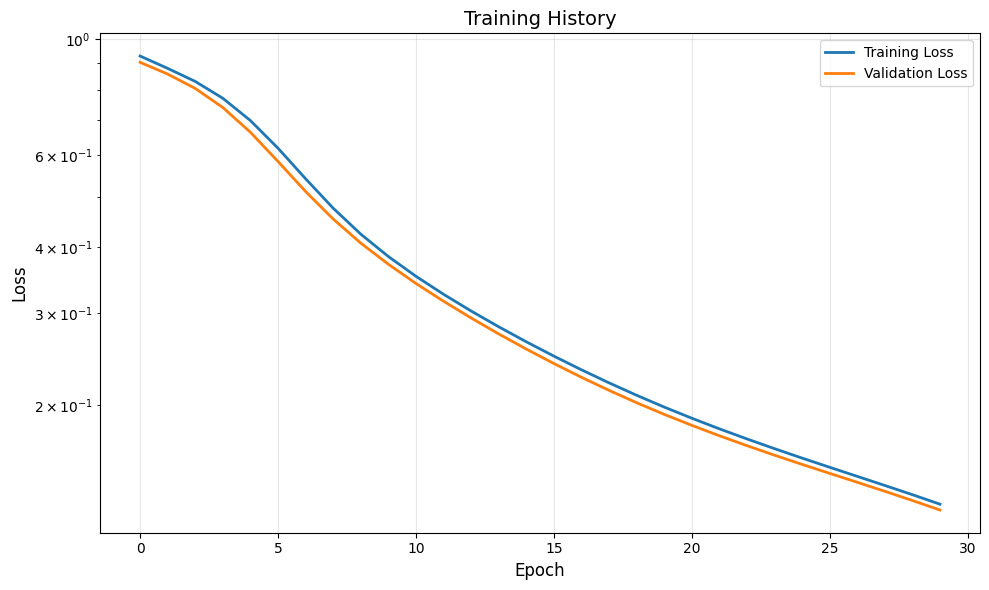

In [ ]:
# ============================================================================
# Cell 11: Plot Training History
# ============================================================================

print("=" * 60)
print("Training History Plot")
print("=" * 60)

trainer.plot_training_history()

In [ ]:
# ============================================================================
# Cell 12: Test Predictions on Validation Data
# ============================================================================

print("=" * 60)
print("Testing Predictions on Validation Data")
print("=" * 60)

n_test = min(5, len(val_data))
print(f"\nTesting on {n_test} validation samples:")
print("-" * 80)

errors = []
for i in range(n_test):
    D1, D2, target = val_data[i]

    D_pred = trainer.predict(D1, D2)
    error = trainer.compute_cost(D_pred, target)
    errors.append(error)

    print(f"\nSample {i+1}:")
    print(f"  Phase 1 D11: {D1.D[0]:.4f}, Phase 2 D11: {D2.D[0]:.4f}")
    print(f"  Target D11: {target.D[0]:.4f}, Predicted D11: {D_pred.D[0]:.4f}")
    print(f"  Relative error: {error:.6f}")

print(f"\n✓ Average error on {n_test} samples: {np.mean(errors):.6f}")

Testing Predictions on Validation Data

Testing on 5 validation samples:
--------------------------------------------------------------------------------

Sample 1:
  Phase 1 D11: -0.0750, Phase 2 D11: -0.1384
  Target D11: 3.1041, Predicted D11: 0.0445
  Relative error: 0.513152

Sample 2:
  Phase 1 D11: -0.6570, Phase 2 D11: -0.3122
  Target D11: 0.1877, Predicted D11: -0.3125
  Relative error: 1.017389

Sample 3:
  Phase 1 D11: -0.2878, Phase 2 D11: -0.3121
  Target D11: 0.6267, Predicted D11: -0.2039
  Relative error: 0.895323

Sample 4:
  Phase 1 D11: -0.4198, Phase 2 D11: -0.2943
  Target D11: 1.4175, Predicted D11: -0.6755
  Relative error: 0.910909

Sample 5:
  Phase 1 D11: 0.5421, Phase 2 D11: 3.3345
  Target D11: 5.5084, Predicted D11: 0.8121
  Relative error: 0.564564

✓ Average error on 5 samples: 0.780267


In [ ]:
# ============================================================================
# Cell 12: Test Predictions on Validation Data (FIXED - REAL SPACE)
# ============================================================================

print("=" * 60)
print("Testing Predictions on Validation Data (REAL SPACE)")
print("=" * 60)

n_test = min(5, len(val_data))
print(f"\nTesting on {n_test} validation samples:")
print("-" * 80)

errors = []

for i in range(n_test):
    D1, D2, target = val_data[i]

    # Prediction (LOG SPACE)
    D_pred = trainer.predict(D1, D2)

    # =========================
    # CONVERT TO REAL SPACE
    # =========================
    D1_real = np.exp(D1.D)
    D2_real = np.exp(D2.D)
    target_real = np.exp(target.D)
    pred_real = np.exp(D_pred.D)

    # =========================
    # RELATIVE ERROR (REAL SPACE)
    # =========================
    error = np.mean(np.abs(pred_real - target_real) / (np.abs(target_real) + 1e-8))
    errors.append(error)

    print(f"\nSample {i+1}:")
    print(f"  Phase 1 D11: {D1_real[0]:.4f}, Phase 2 D11: {D2_real[0]:.4f}")
    print(f"  Target D11: {target_real[0]:.4f}, Predicted D11: {pred_real[0]:.4f}")
    print(f"  Relative error: {error:.6f}")

print(f"\n✓ Average error on {n_test} samples: {np.mean(errors):.6f}")

Testing Predictions on Validation Data (REAL SPACE)

Testing on 5 validation samples:
--------------------------------------------------------------------------------

Sample 1:
  Phase 1 D11: 1.1205, Phase 2 D11: 0.0643
  Target D11: 0.5982, Predicted D11: 11.4365
  Relative error: 643.068019

Sample 2:
  Phase 1 D11: 2.5553, Phase 2 D11: 22.5510
  Target D11: 3.8183, Predicted D11: 28.6670
  Relative error: 620.826975

Sample 3:
  Phase 1 D11: 2.5044, Phase 2 D11: 2.7273
  Target D11: 2.5251, Predicted D11: 28.6806
  Relative error: 192.482445

Sample 4:
  Phase 1 D11: 1.7605, Phase 2 D11: 1.5716
  Target D11: 1.7008, Predicted D11: 19.7850
  Relative error: 656.012387

Sample 5:
  Phase 1 D11: 3.0231, Phase 2 D11: 2.3259
  Target D11: 2.7832, Predicted D11: 35.1191
  Relative error: 793.362653

✓ Average error on 5 samples: 581.150496


Network Structure Visualization
Plotting network structure...


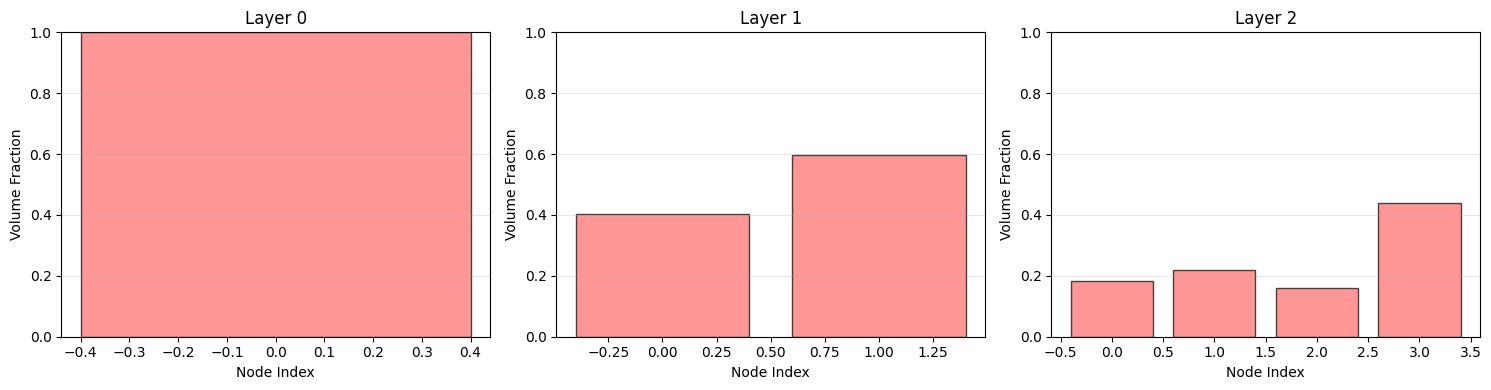

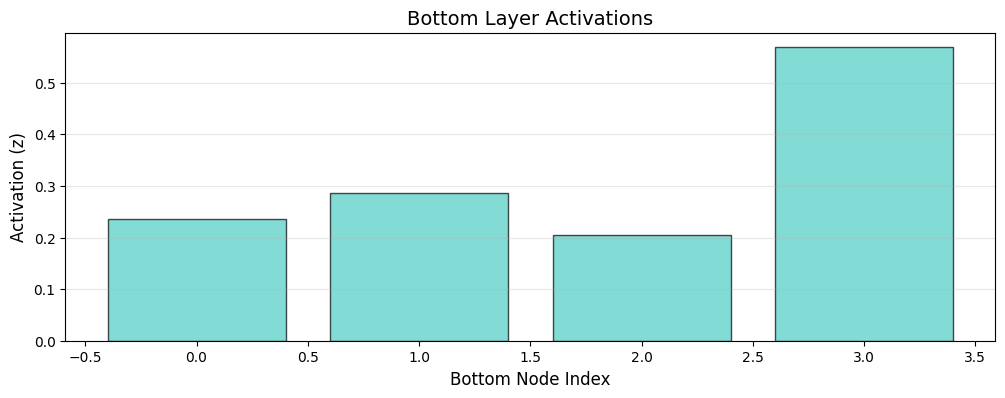

In [ ]:
# ============================================================================
# Cell 14: Visualize Network Structure
# ============================================================================

print("=" * 60)
print("Network Structure Visualization")
print("=" * 60)

def plot_network_structure(network):
    """Simple visualization of volume fractions at different layers"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    layers_to_plot = [0, 1, 2]  # Output layer, layer 1, layer 2

    for idx, layer in enumerate(layers_to_plot):
        ax = axes[idx]
        n_nodes = 2**layer if layer > 0 else 1

        vfs = []
        for node in range(n_nodes):
            vf = network.get_volume_fraction(node, layer)
            vfs.append(vf)

        colors = ['#FF6B6B' if vf > 0 else '#4ECDC4' for vf in vfs]
        ax.bar(range(len(vfs)), vfs, color=colors, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Node Index', fontsize=10)
        ax.set_ylabel('Volume Fraction', fontsize=10)
        ax.set_title(f'Layer {layer}', fontsize=12)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

print("Plotting network structure...")
plot_network_structure(network)

# Plot bottom layer activations
plt.figure(figsize=(12, 4))
plt.bar(range(len(network.z)), network.relu(network.z), color='#4ECDC4', alpha=0.7, edgecolor='black')
plt.xlabel('Bottom Node Index', fontsize=12)
plt.ylabel('Activation (z)', fontsize=12)
plt.title('Bottom Layer Activations', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# ============================================================================
# Cell 15: Save and Load Model
# ============================================================================

print("=" * 60)
print("Saving Model")
print("=" * 60)

def save_model(network, filename='dmn_model.npz'):
    """Save network parameters to file"""
    np.savez(filename,
             depth=network.depth,
             n_phases=network.n_phases,
             z=network.z,
             theta=np.array(network.theta, dtype=object))
    print(f"✓ Model saved to {filename}")

def load_model(filename='dmn_model.npz'):
    """Load network parameters from file"""
    data = np.load(filename, allow_pickle=True)
    network = MaterialNetwork(depth=int(data['depth']))
    network.z = data['z']
    network.theta = list(data['theta'])
    network.update_weights_from_z()
    print(f"✓ Model loaded from {filename}")
    return network

# Save the trained model
save_model(network)

# Test loading
loaded_network = load_model()
print(f"\nLoaded network info:")
loaded_network.print_network_info()

Saving Model
✓ Model saved to dmn_model.npz
✓ Model loaded from dmn_model.npz

Loaded network info:
Network depth: 2
Number of bottom nodes: 4
Number of active nodes: 4
Volume fractions sum: 1.0000


In [ ]:
# ============================================================================
# Cell 16: Batch Prediction Example
# ============================================================================

print("=" * 60)
print("Batch Prediction Example")
print("=" * 60)

def batch_predict(trainer, data_list):
    """Predict for multiple samples"""
    predictions = []
    for D1, D2, _ in data_list:
        D_pred = trainer.predict(D1, D2)
        predictions.append(D_pred)
    return predictions

# Test on validation data
n_batch = min(10, len(val_data))
test_batch = val_data[:n_batch]

print(f"Predicting for {n_batch} samples...")
start_time = time.time()
predictions = batch_predict(trainer, test_batch)
end_time = time.time()

print(f"✓ Prediction time: {(end_time - start_time)*1000:.2f} ms")
print(f"✓ Average time per sample: {(end_time - start_time)*1000/n_batch:.2f} ms")

# Show predictions
print("\nFirst 3 predictions (D11 component):")
for i in range(min(3, n_batch)):
    D1, D2, target = test_batch[i]
    print(f"  Sample {i+1}: Target D11={target.D[0]:.4f}, Predicted D11={predictions[i].D[0]:.4f}")

Batch Prediction Example
Predicting for 2 samples...
✓ Prediction time: 0.72 ms
✓ Average time per sample: 0.36 ms

First 3 predictions (D11 component):
  Sample 1: Target D11=1.0501, Predicted D11=0.6198
  Sample 2: Target D11=0.3691, Predicted D11=1.8083
